In [52]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

In [25]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [39]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((.5, .5, .5), (.5, .5, .5))
])

# Make dataset with image folder
dataset = datasets.ImageFolder(root='./dataset', transform=transform)

# Split dataset into train and val
train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, test_size])

# Create dataloader for train and val
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, drop_last=True)

print(f'Classes: {dataset.classes}')
print(f'Train instances: {len(train_dataset)}')
print(f'Val instances: {len(val_dataset)}')

Classes: ['with_mask', 'without_mask']
Train instances: 6042
Val instances: 1511


In [14]:
def im_convert(tensor):
  image = tensor.cpu().clone().detach().numpy()
  image = image.transpose(1, 2, 0)
  image = image * np.array((0.5, 0.5, 0.5)) + np.array((0.5, 0.5, 0.5))
  image = image.clip(0, 1)
  return image

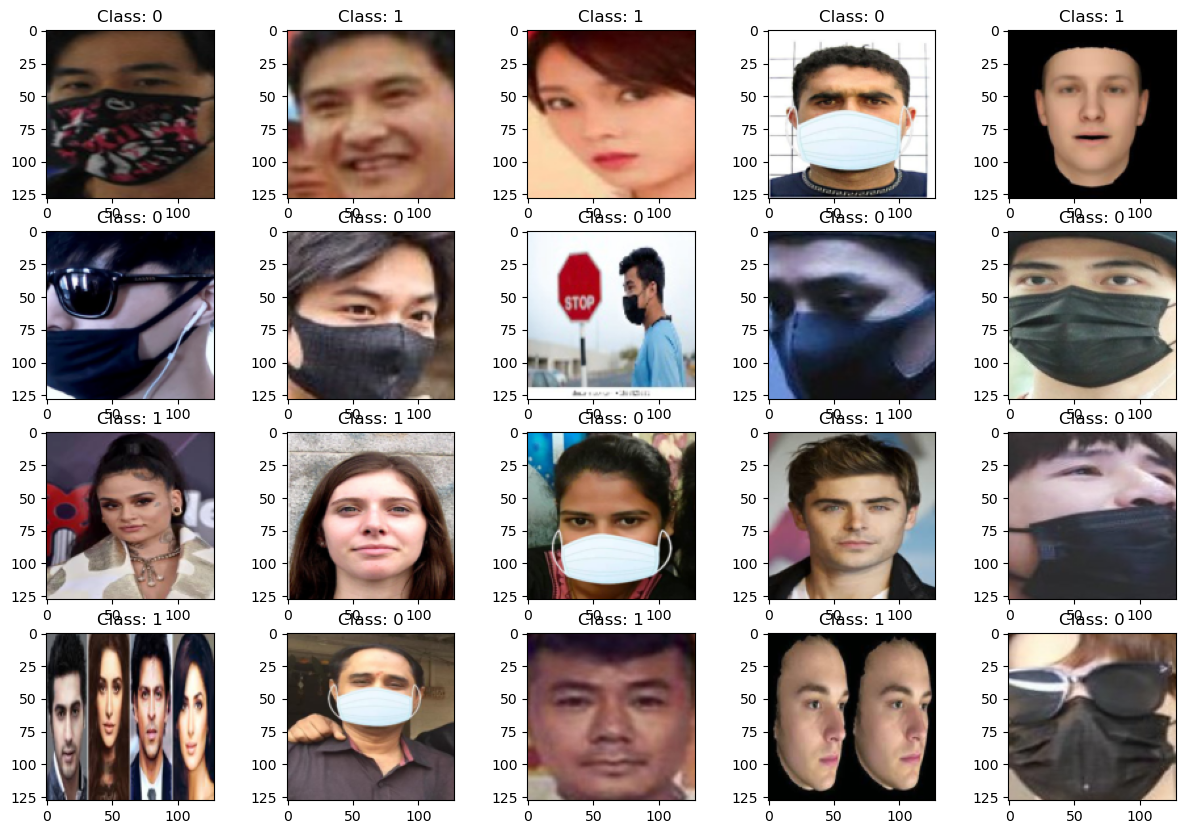

In [20]:
images, labels = next(iter(train_loader))

fig = plt.figure(figsize=(15, 10))
for idx in range(20):
    ax = fig.add_subplot(4, 5, idx+1)
    plt.imshow(im_convert(images[idx]))
    ax.set_title(f'Class: {labels[idx].item()}')

In [40]:
# Designing a CNN model
class MaskCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # (3, 128, 128)
        self.conv1 = nn.Conv2d(3, 16, 5, 3, 1) 
        self.conv2 = nn.Conv2d(16, 32, 5, 3, 1) 
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 2)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [41]:
model = MaskCNN().to(device)
model

MaskCNN(
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(3, 3), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(3, 3), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=288, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

In [42]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [44]:
num_epochs = 10

loss_history = []
corrects_history = []
val_loss_history = []
val_corrects_history = []
for epoch in range(num_epochs):
    running_loss = 0.0
    running_corrects = 0.0
    val_running_loss = 0.0
    val_running_corrects = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        
        running_loss += loss.item()
        running_corrects += torch.sum(preds == labels.data)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    else:
        with torch.no_grad():
            for val_images, val_labels in val_loader:
                val_images, val_labels = val_images.to(device), val_labels.to(device)

                val_outputs = model(val_images)
                _, val_preds = torch.max(val_outputs, 1)
                val_loss = criterion(val_outputs, val_labels)
        
                val_running_loss += val_loss.item()
                val_running_corrects += torch.sum(val_preds == val_labels.data)
            
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = running_corrects.float() / len(train_loader.dataset)
        val_epoch_loss = val_running_loss / len(val_loader)
        val_epoch_acc = val_running_corrects.float() / len(val_loader.dataset)
        
        loss_history.append(epoch_loss)
        corrects_history.append(epoch_acc)
        val_loss_history.append(val_epoch_loss)
        val_corrects_history.append(val_epoch_acc)

        print('\nEpoch :', (epoch+1))
        print('Training loss: {:.4f}, acc {:.4f} '.format(epoch_loss, epoch_acc.item()))
        print('Validation loss: {:.4f}, validation acc {:.4f} '.format(val_epoch_loss, val_epoch_acc.item()))


Epoch : 1
Training loss: 0.1082, acc 0.9581 
Validation loss: 0.1661, validation acc 0.9179 

Epoch : 2
Training loss: 0.0980, acc 0.9601 
Validation loss: 0.1587, validation acc 0.9206 

Epoch : 3
Training loss: 0.0879, acc 0.9646 
Validation loss: 0.1571, validation acc 0.9153 

Epoch : 4
Training loss: 0.0735, acc 0.9725 
Validation loss: 0.1515, validation acc 0.9226 

Epoch : 5
Training loss: 0.0680, acc 0.9735 
Validation loss: 0.1647, validation acc 0.9199 

Epoch : 6
Training loss: 0.0565, acc 0.9768 
Validation loss: 0.1744, validation acc 0.9199 

Epoch : 7
Training loss: 0.0511, acc 0.9777 
Validation loss: 0.1936, validation acc 0.9140 

Epoch : 8
Training loss: 0.0475, acc 0.9811 
Validation loss: 0.1957, validation acc 0.9126 

Epoch : 9
Training loss: 0.0442, acc 0.9786 
Validation loss: 0.2506, validation acc 0.9067 

Epoch : 10
Training loss: 0.0339, acc 0.9839 
Validation loss: 0.1909, validation acc 0.9226 


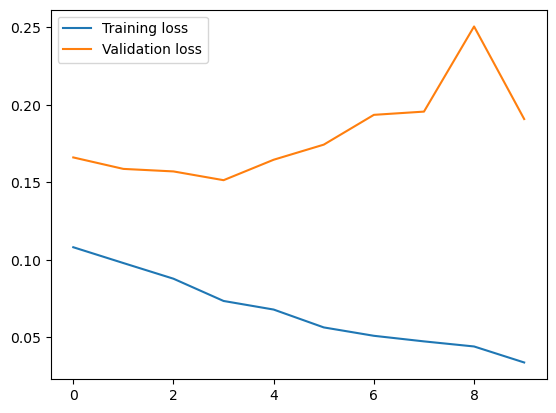

In [45]:
plt.plot(loss_history, label='Training loss')
plt.plot(val_loss_history, label='Validation loss')
plt.legend()
plt.show()

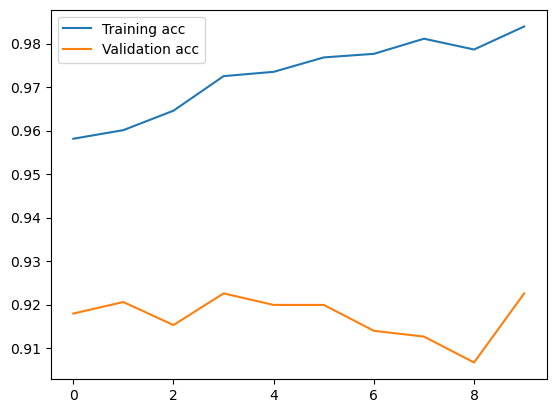

In [47]:
plt.plot([x.cpu().item() for x in corrects_history], label='Training acc')
plt.plot([x.cpu().item() for x in val_corrects_history], label='Validation acc')
plt.legend()
plt.show()

In [48]:
# Saving the model
torch.save(model.state_dict(), "mask_detector.pth")

# Loading the model
# model.load_state_dict(torch.load("mask_detector.pth"))
# model.eval()

In [50]:
# Define a function to predict new image
def predict_mask(model, image_path):
    model.eval()
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, pred = torch.max(output, 1)
    return "Mask" if pred.item() == 0 else "No Mask"


In [53]:
predict_mask(model, './test_1.jpg')

'Mask'

In [54]:
!conda env list


# conda environments:
#
base                 * C:\Users\Mahdi\anaconda3

